In [4]:
import numpy as np
import netCDF4 as nc
import glob
import os
import json
import toml
from scipy.interpolate import PchipInterpolator

import matplotlib as mpl
font = {'family' : 'sans',
        'size'   : 12}

mpl.rc('font', **font)
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, LogLocator, MaxNLocator
import matplotlib.pyplot as plt

import matplotlib.patheffects as pe

import pandas as pd
from cmcrameri import cm

from utils.load_grid import _recursive_get, descend_get, M_earth, R_earth

In [35]:
def get_bo_run(output_dir):

    # Read BO config file
    config_path = os.path.join(output_dir, "copy.infer.toml")
    infer_conf = toml.load(config_path)
    obs = infer_conf['observables']
    prs = infer_conf['parameters']

    # Extract log of BO run
    fpath = os.path.join(output_dir, "logs.csv")
    log = []
    best_obj = -np.inf
    with open(fpath, 'r') as f:
        for line in f.readlines():
            if '{' not in line:
                continue
            line = line.replace("'", '"').replace("None", "1.0")[1:-2]
            json_line = json.loads(line) # parse json into dict
            log.append(json_line)

            if json_line['y_value'] > best_obj:
                best_obj = json_line['y_value']

    # Mark best worker
    for run in log:
        run['is_best'] = run['y_value'] == best_obj

    # For each worker, read helpfile
    helps = []
    for run in log:
        wk = run['worker']
        id = run['task_id']
        help_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "runtime_helpfile.csv")
        helps.append(pd.read_csv(help_path, delimiter=r"\s+"))

    # For each worker, read config
    confs = []
    for run in log:
        wk = run['worker']
        id = run['task_id']
        conf_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "input.toml")
        confs.append(toml.load(conf_path))

    # Package into dict
    bo_run = {
        "config": infer_conf,
        "log": log,
        "helps": helps,
        "confs": confs,
        "obs": obs,
        "prs": prs,
    }
    return bo_run

def get_gt_run(gt_dir):

    # Read GT config file
    config_path = os.path.join(gt_dir, "init_coupler.toml")
    gt_conf = toml.load(config_path)

    # Read GT helpfile
    help_path = os.path.join(gt_dir, "runtime_helpfile.csv")
    gt_help = pd.read_csv(help_path, delimiter=r"\s+")

    gt_run = {
        "config": gt_conf,
        "help": gt_help,
    }
    return gt_run

bo_suffixes = ('sn', 'se', 'tr')

# Read ground truth configs
ground_truth  = {suf: get_gt_run(f"data/bayesopt_{suf}/") for suf in bo_suffixes}

# Plotting parameters
bo_cols = ('tab:blue', 'tab:orange', 'tab:green')
bo_tits = ('Sub-Neptune', 'Super-Earth', 'Terrestrial')

# Read inference results
bo_data = {suf: get_bo_run(f"data/bayesopt_infer_{suf}/") for suf in bo_suffixes}

obs_list = list(bo_data['se']['obs'].keys())
prs_list = list(bo_data['se']['prs'].keys())

## Plot simulations resolving towards observables

Parameters: ['params.stop.time.maximum', 'orbit.semimajoraxis', 'struct.mass_tot', 'struct.corefrac', 'outgas.fO2_shift_IW', 'delivery.elements.H_ppmw', 'delivery.elements.CH_ratio', 'delivery.elements.SH_ratio']


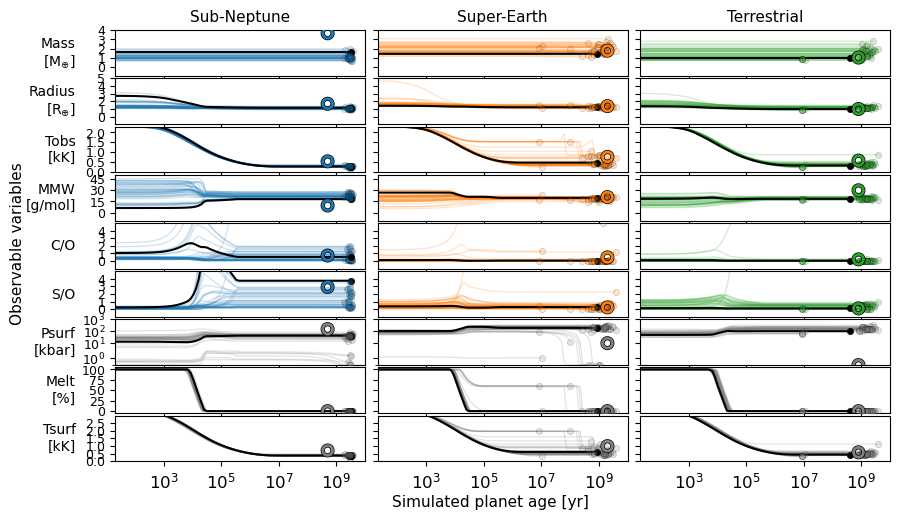

In [128]:
print("Parameters:", prs_list)
yvars = obs_list +['P_surf', 'Phi_global', 'T_surf']
N_yv = len(yvars)
N_bo = len(bo_data)

fig,axs = plt.subplots(N_yv,N_bo,figsize=(10,2+N_yv*0.4))

# for each y-variable
for iax in range(N_yv):
    key = yvars[iax]

    scale = 1
    yscl = "linear"
    ylim=None
    ytck = None
    ylbl = key
    if key == "M_planet":
        scale = M_earth
        ylim  = [-1, 4]
        ytck  = [0, 1, 2, 3, 4]
        ylbl  = "Mass\n" + r"[M$_{\oplus}$]"
    elif key == "R_obs":
        scale = R_earth
        ylim = [-1, 5]
        ytck = [0, 1, 2, 3, 4, 5]
        ylbl  = "Radius\n" + r"[R$_{\oplus}$]"
    elif key == "T_obs":
        scale = 1e3
        ylim = [-0.02, 2.3]
        ylbl  = "Tobs\n" + r"[kK]"
        ytck = [0, 0.5, 1.0, 1.5, 2.0]
    elif key == "atm_kg_per_mol":
        scale = 1e-3
        ylim = [-10, 50]
        ylbl = "MMW\n[g/mol]"
        ytck = [0, 15, 30, 45]
    elif key in ["C/O_atm", "S/O_atm"]:
        scale = 1
        ylim = [-1, 5]
        ytck = [0, 1, 2, 3, 4]
        ylbl = key.split("_")[0]
    elif key == "P_surf":
        scale = 1e3
        ylim = [0, 1e3]
        ylbl = "Psurf\n[kbar]"
        yscl = "symlog"
        ytck = [1, 10, 100, 1000]
    elif key == "Phi_global":
        scale = 1e-2
        ylim = [-5, 105.0]
        ylbl = "Melt\n[%]"
        ytck = [0, 25, 50, 75, 100]
    elif key == "T_surf":
        scale = 1e3
        ylim = [-0.02, 3.0]
        ylbl  = "Tsurf\n" + r"[kK]"
        ytck = [0, 0.5, 1.0, 1.5, 2.0, 2.5]


    # for each BO run
    for jax, suf in enumerate(bo_suffixes):

        ax = axs[iax, jax]

        bo = bo_data[suf]
        helps      = bo['helps']
        confs      = bo['confs']
        obs_this   = bo['obs']  # observables for this BO run
        prs_this   = bo['prs']  # parameters ranges for this BO run

        is_observable = key in obs_list
        col = bo_cols[jax]

        xmax = 1e8

        # plot simulations from this BO run
        for isim in range(len(helps)):
            help = helps[isim]
            conf = confs[isim]
            x = help['Time']
            y = help[key] / scale

            alp = bo['log'][isim]['y_value'] # value of objective (best=1)
            alp = max(alp, 0.2)

            if bo['log'][isim]['is_best']:
                col_sim = 'k'
                lw_sim = 1.5
                zorder_sim = 5
                alp = 1.0
            else:
                if is_observable:
                    col_sim = col
                else:
                    col_sim = 'grey'
                lw_sim = 1
                zorder_sim = 1

            # sort x and remove duplicate times
            mask = np.argsort(x) & (x>1)
            x = np.array(x)[mask]
            y = np.array(y)[mask]
            xmax = max(xmax, max(x))

            # interpolate to get smoother lines
            if len(x) > 3:
                x_plt = np.logspace(np.log10(min(x)), np.log10(max(x)), 100)
                y_plt = PchipInterpolator(x, y)(x_plt)
            else:
                x_plt = x
                y_plt = y
            ax.plot(x_plt, y_plt, color=col_sim, alpha=alp, linewidth=lw_sim, zorder=zorder_sim)

            # add scatter point at end of simulation
            ax.scatter(x[-1], y[-1], color=col_sim, alpha=alp, edgecolor='k', s=20, zorder=10, lw=0.5)

        # plot truths
        if not is_observable:
            col = 'grey'
        obs_tru = ground_truth[suf]['help'][key].iloc[-1] / scale
        obs_age = descend_get(ground_truth[suf]['config'], 'params.stop.time.maximum')
        ax.scatter(obs_age, obs_tru, color='none', edgecolor=col, s=50, zorder=10, lw=2,
                path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])

        ax.set_xscale("log")
        ax.set_xlim(left=2e1, right=1e10)
        ax.set_ylim(ylim)
        ax.set_yscale(yscl)
        if ytck is not None:
            ax.set_yticks(ytck)
        if jax == 0:
            ax.set_ylabel(ylbl, rotation=0, ha='right', va='center', fontsize=10)
            ax.tick_params(axis='y', which='major', labelsize=9)
        else:
            ax.set_yticklabels([])

        if iax == 0:
            ax.set_title(bo_tits[jax], fontsize=11)
        if iax == N_yv - 1:
            # ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))
            pass
        else:
            ax.set_xticklabels([])

fig.supylabel("Observable variables", fontsize=11)
fig.supxlabel("Simulated planet age [yr]", va='top', fontsize=11, y=0.05)
fig.align_ylabels()
fig.subplots_adjust(wspace=0.05, hspace=0.05)

plt.show()
fig.savefig("output/bo_evolve.pdf", bbox_inches='tight', dpi=300, pad_inches=0.01)

## Plot retrieval resolving ground truth parameters

Parameters: ['params.stop.time.maximum', 'orbit.semimajoraxis', 'struct.mass_tot', 'struct.corefrac', 'outgas.fO2_shift_IW', 'delivery.elements.H_ppmw', 'delivery.elements.CH_ratio', 'delivery.elements.SH_ratio']


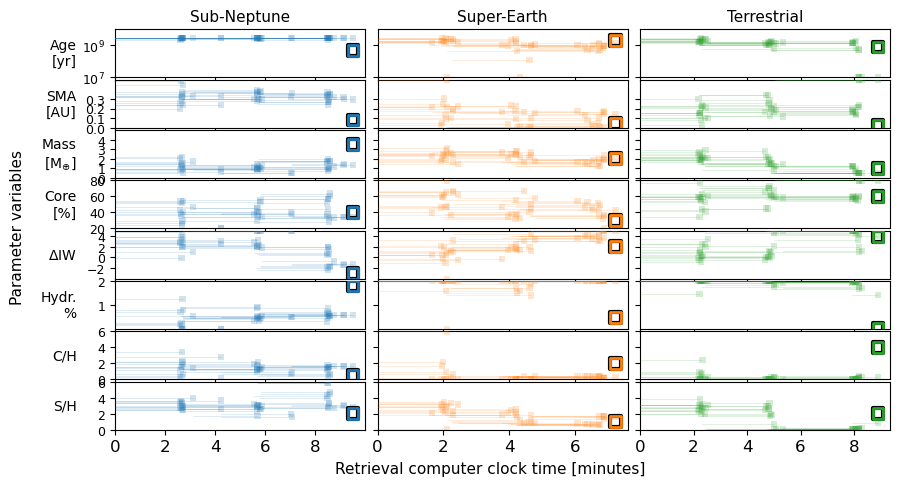

In [127]:
print("Parameters:", prs_list)
N_pa = len(prs_list)
N_bo = len(bo_data)

fig,axs = plt.subplots(N_pa,N_bo,figsize=(10,2+N_pa*0.4))

# for each parameter
for iax in range(N_pa):
    key = prs_list[iax]

    scale = 1
    yscl = "linear"
    ytck = None
    ylbl = key
    ylim = None

    if key == "params.stop.time.maximum":
        ylbl  = "Age\n" + r"[yr]"
        yscl = "log"
        ylim = [1e7,1e10]
    elif key == "orbit.semimajoraxis":
        ylbl  = "SMA\n" + r"[AU]"
        ytck = [0, .1, .2, .3,]
    elif key == "struct.mass_tot":
        ylbl  = "Mass\n" + r"[M$_{\oplus}$]"
        ytck = [0, 1, 2, 3, 4]
    elif key == 'struct.corefrac':
        scale = 1e-2
        ylbl = "Core\n[%]"
        ytck = [20, 40, 60, 80]
    elif key == 'outgas.fO2_shift_IW':
        ylbl = r"$\Delta$" + "IW"
        ytck = [-2, 0, 2, 4]
    elif key == "delivery.elements.H_ppmw":
        scale = 1e6/1e2
        ylbl = "Hydr.\n%"
    elif key == "delivery.elements.CH_ratio":
        ylbl = "C/H"
        ytck = [0, 2, 4, 6]
    elif key == "delivery.elements.SH_ratio":
        ylbl  = "S/H"
        ytck = [0, 2, 4, 6]

    if ylim is None:
        ylim = np.array([bo_data['se']['config']['parameters'][key]][0]) / scale


    # for each BO run
    for jax, suf in enumerate(bo_suffixes):

        ax = axs[iax, jax]

        bo = bo_data[suf]
        log = bo['log']
        helps      = bo['helps']
        confs      = bo['confs']
        obs_this   = bo['obs']  # observables for this BO run
        prs_this   = bo['prs']  # parameters ranges for this BO run

        N_wk = np.amax([run['worker'] for run in log]) + 1
        col = bo_cols[jax]

        # get xmin from all cases
        tmin = np.inf
        xmax = -np.inf
        for isim in range(len(log)):
            tmin = min(tmin, log[isim]['start_time'])

        # get values for each worker process
        for isim in range(len(log)):
            t0 = (log[isim]['start_time'] - tmin) / 60
            t1 = (log[isim]['end_time'] - tmin) / 60
            yv = descend_get(confs[isim], key) / scale
            xmax = max(xmax, t1)

            alp = log[isim]['y_value'] # value of objective (best=1)
            alp = max(alp, 0.2)

            ax.plot([t0,t1], [yv, yv], color=col, alpha=alp, zorder=10, lw=0.5, linestyle='-')
            ax.scatter(t1, yv, color=col, alpha=alp, edgecolor='none',
                       s=20, zorder=10, lw=0.5, marker='s')

        # plot true value on this parameter
        par_tru = descend_get(ground_truth[suf]['config'],key)/scale
        ax.scatter(xmax, par_tru, marker='s', color='none', edgecolor=col, s=60, zorder=100, lw=2,
                   path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])

        ax.set_xlim(0, xmax*1.05)
        ax.set_ylim(ylim)
        ax.set_yscale(yscl)
        if ytck is not None:
            ax.set_yticks(ytck)
        if jax == 0:
            ax.set_ylabel(ylbl, rotation=0, ha='right', va='center', fontsize=10)
            ax.tick_params(axis='y', which='major', labelsize=9)
        else:
            ax.set_yticklabels([])

        if iax == 0:
            ax.set_title(bo_tits[jax], fontsize=11)
        if iax == N_pa - 1:
            # ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))
            pass
        else:
            ax.set_xticklabels([])

fig.supylabel("Parameter variables", fontsize=11)
fig.supxlabel("Retrieval computer clock time [minutes]", va='top', fontsize=11, y=0.05)
fig.align_ylabels()
fig.subplots_adjust(wspace=0.05, hspace=0.05)

plt.show()
fig.savefig("output/bo_converge.pdf", bbox_inches='tight', dpi=300, pad_inches=0.01)